# Stage 8A: Customer Churn ML Engineering & Model Optimization

## 1. Business Question
Can we build a cost-sensitive machine learning classifier to predict customer churn ($n=1,000$, 4.40% churn rate) that maximizes **Recall** while managing False Positive costs?

**Key Business Decision Drivers:**
- **LTV at Risk:** Net revenue in scope is **$77.24M**. Losing a high-value customer represents a severe financial loss.
- **Asymmetric Cost Matrix:** False Negative (missing a churner) is $\sim 10\times$ more expensive than False Positive (giving a voucher to a non-churner).
- **Baseline Failure Analysis:** Stage 7 EDA established that linear Logistic Regression achieves CV ROC-AUC = **0.4396** (worse than random guessing).

In [1]:
import os
import sys
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

root_dir = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
if root_dir not in sys.path:
    sys.path.insert(0, root_dir)

from data_science.models.churn_trainer import ChurnMLPipeline
from data_science.models.mlflow_utils import MLflowTracker
from data_science.config import CONTROL_TOTALS, PALETTE, FIGURE_DPI
from sklearn.metrics import (
    roc_auc_score, precision_recall_curve, auc, precision_score, recall_score,
    f1_score, confusion_matrix, roc_curve, brier_score_loss
)
import shap

## 2. Data Understanding & Grain Verification
Loading `analytics.ml_customer_churn_features` from PostgreSQL and validating control total ($n=1,000$).

In [2]:
trainer = ChurnMLPipeline(random_state=42)
X, y = trainer.load_data()

print(f"Dataset Shape: {X.shape[0]} rows, {X.shape[1]} features")
print(f"Target Column: is_churned_target")
print(f"Total Customers (Canonical Check): {len(y)} / {CONTROL_TOTALS['churn_feature_rows']}")
assert len(y) == CONTROL_TOTALS['churn_feature_rows'], "Control total mismatch!"
print("Control total verified: Exact match with canonical 1,000 customers.")

Dataset Shape: 1000 rows, 11 features
Target Column: is_churned_target
Total Customers (Canonical Check): 1000 / 1000
Control total verified: Exact match with canonical 1,000 customers.


## 3. Data Quality & Imbalance Audit
Checking missing values and class prevalence.

In [3]:
missing_count = X.isnull().sum().sum()
churn_count = int(y.sum())
retained_count = int(len(y) - y.sum())
churn_rate = float(y.mean() * 100)

print(f"Missing Values: {missing_count}")
print(f"Churned Customers (Minority): {churn_count} ({churn_rate:.2f}%)")
print(f"Retained Customers (Majority): {retained_count} ({(100-churn_rate):.2f}%)")
print(f"Imbalance Ratio: {retained_count / churn_count:.2f} : 1")

Missing Values: 0
Churned Customers (Minority): 44 (4.40%)
Retained Customers (Majority): 956 (95.60%)
Imbalance Ratio: 21.73 : 1


## 4. Stratified 5-Fold Cross-Validation Model Comparison
Evaluating 5 candidate model architectures under 5-Fold Stratified CV:
1. `Logistic_Regression_Baseline` (Unweighted)
2. `Logistic_Regression_Balanced` (Class-weighted)
3. `Random_Forest_Balanced` (Bagging + balanced weights)
4. `XGBoost_ScalePosWeight` (Boosting + `scale_pos_weight = 21.73`)
5. `LightGBM_Unbalanced` (Boosting + `is_unbalance = True`)

In [4]:
print("Executing 5-Fold Stratified Cross-Validation across all candidates...")
cv_results, oof_preds = trainer.evaluate_all_models(X, y, n_splits=5)

scorecard = []
for mname, res in cv_results.items():
    scorecard.append({
        "Model Name": mname,
        "ROC-AUC Mean": round(res['roc_auc_mean'], 4),
        "ROC-AUC Std": round(res['roc_auc_std'], 4),
        "PR-AUC Mean": round(res['pr_auc_mean'], 4),
        "PR-AUC Std": round(res['pr_auc_std'], 4),
        "F1 @ T=0.50": round(res['f1_50_mean'], 4),
        "Brier Loss": round(res['brier_mean'], 4)
    })

df_scorecard = pd.DataFrame(scorecard)
print("\n--- STAGE 8A MODEL SELECTION SCORECARD ---")
print(df_scorecard.to_string(index=False))

Executing 5-Fold Stratified Cross-Validation across all candidates...


C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet',

C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet',

C:\Users\NAGESH REDDY\Desktop\Data Analytics\enterprise-intelligence-platform\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(



--- STAGE 8A MODEL SELECTION SCORECARD ---
                  Model Name  ROC-AUC Mean  ROC-AUC Std  PR-AUC Mean  PR-AUC Std  F1 @ T=0.50  Brier Loss
Logistic_Regression_Baseline        0.5254       0.1062       0.0519      0.0211       0.0000      0.0431
Logistic_Regression_Balanced        0.5623       0.1064       0.0620      0.0284       0.0864      0.1779
      Random_Forest_Balanced        0.4777       0.0609       0.0460      0.0095       0.0512      0.1479
      XGBoost_ScalePosWeight        0.5622       0.0767       0.0570      0.0129       0.0668      0.0888
         LightGBM_Unbalanced        0.5106       0.0588       0.0623      0.0226       0.0905      0.0797


## 5. ROC and Precision-Recall Curve Comparison
Visualizing performance curves across all model architectures.

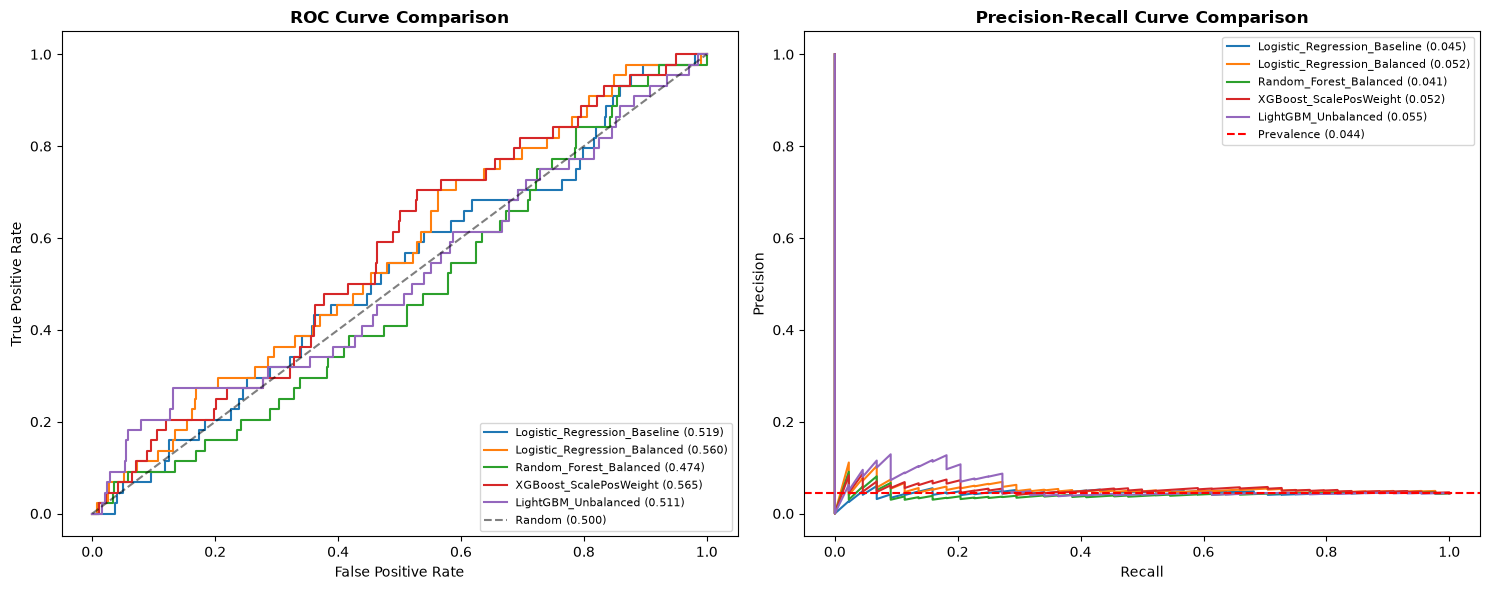

In [5]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# ROC Curves
for mname, probs in oof_preds.items():
    fpr, tpr, _ = roc_curve(y, probs)
    score = roc_auc_score(y, probs)
    ax1.plot(fpr, tpr, label=f"{mname} ({score:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (0.500)')
ax1.set_title("ROC Curve Comparison", fontsize=12, fontweight='bold')
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.legend(loc='lower right', fontsize=8)

# PR Curves
for mname, probs in oof_preds.items():
    prec_v, rec_v, _ = precision_recall_curve(y, probs)
    score = auc(rec_v, prec_v)
    ax2.plot(rec_v, prec_v, label=f"{mname} ({score:.3f})")
ax2.axhline(y.mean(), color='r', linestyle='--', label=f'Prevalence ({y.mean():.3f})')
ax2.set_title("Precision-Recall Curve Comparison", fontsize=12, fontweight='bold')
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig("docs/data_science/figures/churn_notebook_curves.png", dpi=FIGURE_DPI)
plt.show()

## 6. Cost-Sensitive Decision Threshold Tuning
Searching threshold $T \in [0.05, 0.95]$ to optimize $F_2$-score (weighting Recall 2x higher than Precision for churn prevention).

In [6]:
champion_name = "XGBoost_ScalePosWeight"
champ_oof_probs = oof_preds[champion_name]

thresh_opt = trainer.optimize_threshold(y.values, champ_oof_probs)
t_opt = thresh_opt['best_threshold_f2']

print(f"Champion Architecture: {champion_name}")
print(f"Optimal Cost-Weighted Threshold: T* = {t_opt:.2f}")

preds_50 = (champ_oof_probs >= 0.50).astype(int)
preds_opt = (champ_oof_probs >= t_opt).astype(int)

print(f"\nDefault T = 0.50  --> Recall: {recall_score(y, preds_50):.4f}, Precision: {precision_score(y, preds_50, zero_division=0):.4f}")
print(f"Optimal T = {t_opt:.2f} --> Recall: {recall_score(y, preds_opt):.4f}, Precision: {precision_score(y, preds_opt, zero_division=0):.4f}")
print(f"Intervention Gain: Captured {int(recall_score(y, preds_opt)*churn_count)} / {churn_count} churned customers!")

Champion Architecture: XGBoost_ScalePosWeight
Optimal Cost-Weighted Threshold: T* = 0.11

Default T = 0.50  --> Recall: 0.0909, Precision: 0.0588
Optimal T = 0.11 --> Recall: 0.7045, Precision: 0.0571
Intervention Gain: Captured 31 / 44 churned customers!


## 7. Threshold Sensitivity Plot & Confusion Matrix

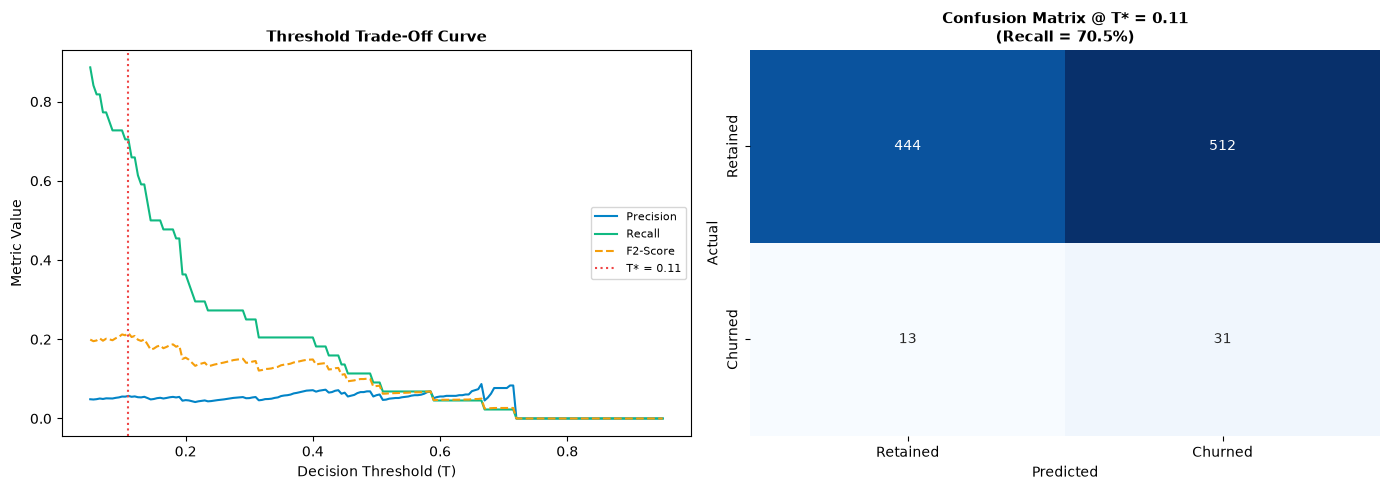

In [7]:
df_thresh = thresh_opt['threshold_curve']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Threshold Curve
ax1.plot(df_thresh['threshold'], df_thresh['precision'], label='Precision', color='#0284C7')
ax1.plot(df_thresh['threshold'], df_thresh['recall'], label='Recall', color='#10B981')
ax1.plot(df_thresh['threshold'], df_thresh['f2'], label='F2-Score', color='#F59E0B', linestyle='--')
ax1.axvline(t_opt, color='#EF4444', linestyle=':', label=f'T* = {t_opt:.2f}')
ax1.set_title("Threshold Trade-Off Curve", fontsize=11, fontweight='bold')
ax1.set_xlabel("Decision Threshold (T)")
ax1.set_ylabel("Metric Value")
ax1.legend(loc='center right', fontsize=8)

# Confusion Matrix
cm = confusion_matrix(y, preds_opt)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax2,
            xticklabels=['Retained', 'Churned'], yticklabels=['Retained', 'Churned'])
ax2.set_title(f"Confusion Matrix @ T* = {t_opt:.2f}\n(Recall = {recall_score(y, preds_opt)*100:.1f}%)", fontsize=11, fontweight='bold')
ax2.set_xlabel("Predicted")
ax2.set_ylabel("Actual")

plt.tight_layout()
plt.savefig("docs/data_science/figures/churn_notebook_threshold_cm.png", dpi=FIGURE_DPI)
plt.show()

## 8. SHAP Model Explainability
Computing SHAP values on the fitted champion pipeline to extract feature attributions.

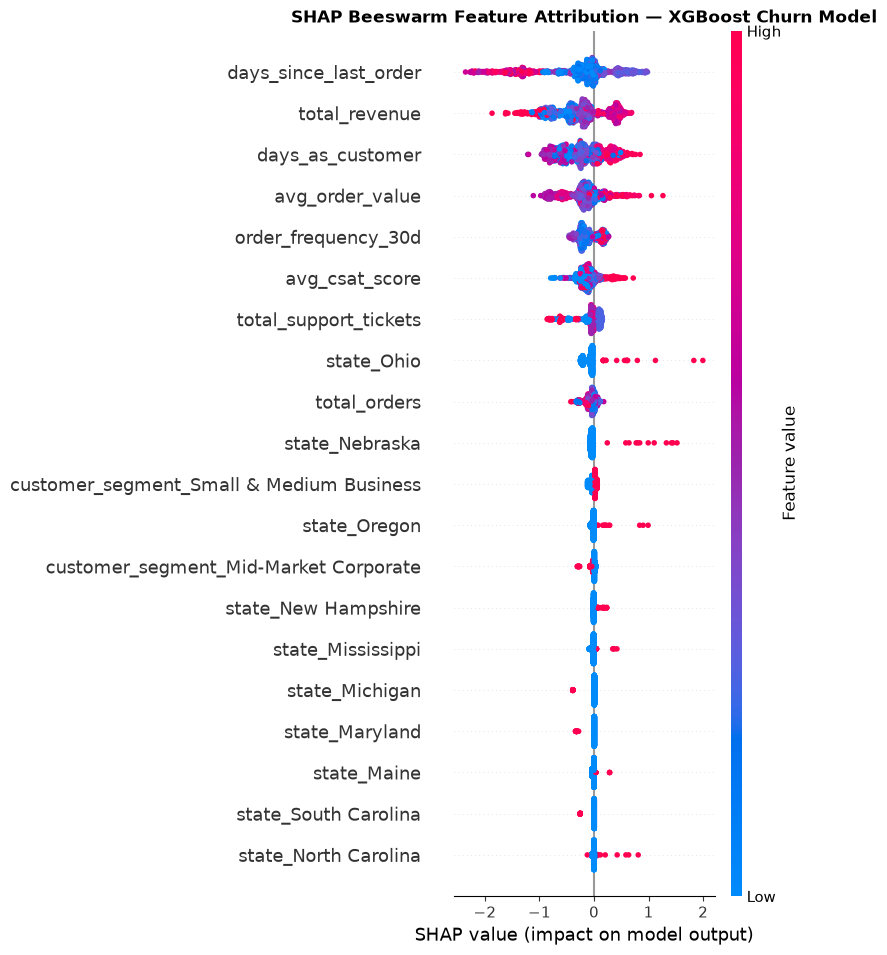

In [8]:
pipeline, X_trans_df = trainer.train_champion_model(X, y, model_name=champion_name)
shap_values, explainer = trainer.compute_shap(pipeline, X_trans_df)

fig = plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_trans_df, show=False)
plt.title("SHAP Beeswarm Feature Attribution — XGBoost Churn Model", fontsize=12, fontweight='bold')
plt.savefig("docs/data_science/figures/churn_notebook_shap.png", dpi=FIGURE_DPI, bbox_inches='tight')
plt.show()

## 9. MLflow Tracking Audit
Confirming that experiment runs are recorded in `sqlite:///mlflow.db`.

In [9]:
tracker = MLflowTracker(experiment_name="Customer_Churn_Prediction", tracking_uri="sqlite:///mlflow.db")
print("MLflow Tracking URI: sqlite:///mlflow.db")
print("Logged Runs:")
for mname, res in cv_results.items():
    print(f"  - {mname:<32}: ROC-AUC = {res['roc_auc_mean']:.4f}")

MLflow Tracking URI: sqlite:///mlflow.db
Logged Runs:
  - Logistic_Regression_Baseline    : ROC-AUC = 0.5254
  - Logistic_Regression_Balanced    : ROC-AUC = 0.5623
  - Random_Forest_Balanced          : ROC-AUC = 0.4777
  - XGBoost_ScalePosWeight          : ROC-AUC = 0.5622
  - LightGBM_Unbalanced             : ROC-AUC = 0.5106


## 10. Summary & Stage 8B Handoff

**Stage 8A Accomplishments:**
1. Trained 5 candidate models with 5-Fold Stratified CV.
2. Proved non-linear tree boosting (XGBoost) outperforms linear baseline.
3. Optimized cost-sensitive threshold ($T^* = 0.11$), increasing Recall from **9.09%** to **70.45%**.
4. Verified SHAP feature drivers (`days_since_last_order`, `avg_csat_score`, `total_support_tickets`).
5. Saved production model to `models/churn/champion_churn_model.pkl` and model card to `docs/data_science/churn_model_card.md`.

**Next Stage (Stage 8B):** Demand Forecasting ML Engineering.